# OPTIONAL Workbook for Final Project, Part 3

Your group is welcome to work on a local version of a notebook for this assignment.

This workspace is here if you'd rather not have to install all necessary packages locally.

You can download any json files to your local computer to add them to your local jekyll page.

To download, you can right-click on the file and hit download.  For example, with the following code:

```python
from vega_datasets import data
import altair as alt

source = data.cars()
source.rename(columns={"Miles_per_Gallon":"Miles per Gallon"}, 
              inplace=True)


chart = alt.Chart(source).mark_circle(size=60).encode(
    x='Horsepower',
    y='Miles per Gallon',
    color='Origin',
    tooltip=['Name', 'Origin', 'Horsepower', 'Miles per Gallon']
).interactive()

chart.properties(width='container').save("cars.json")
```

You can download from the side bar like this:

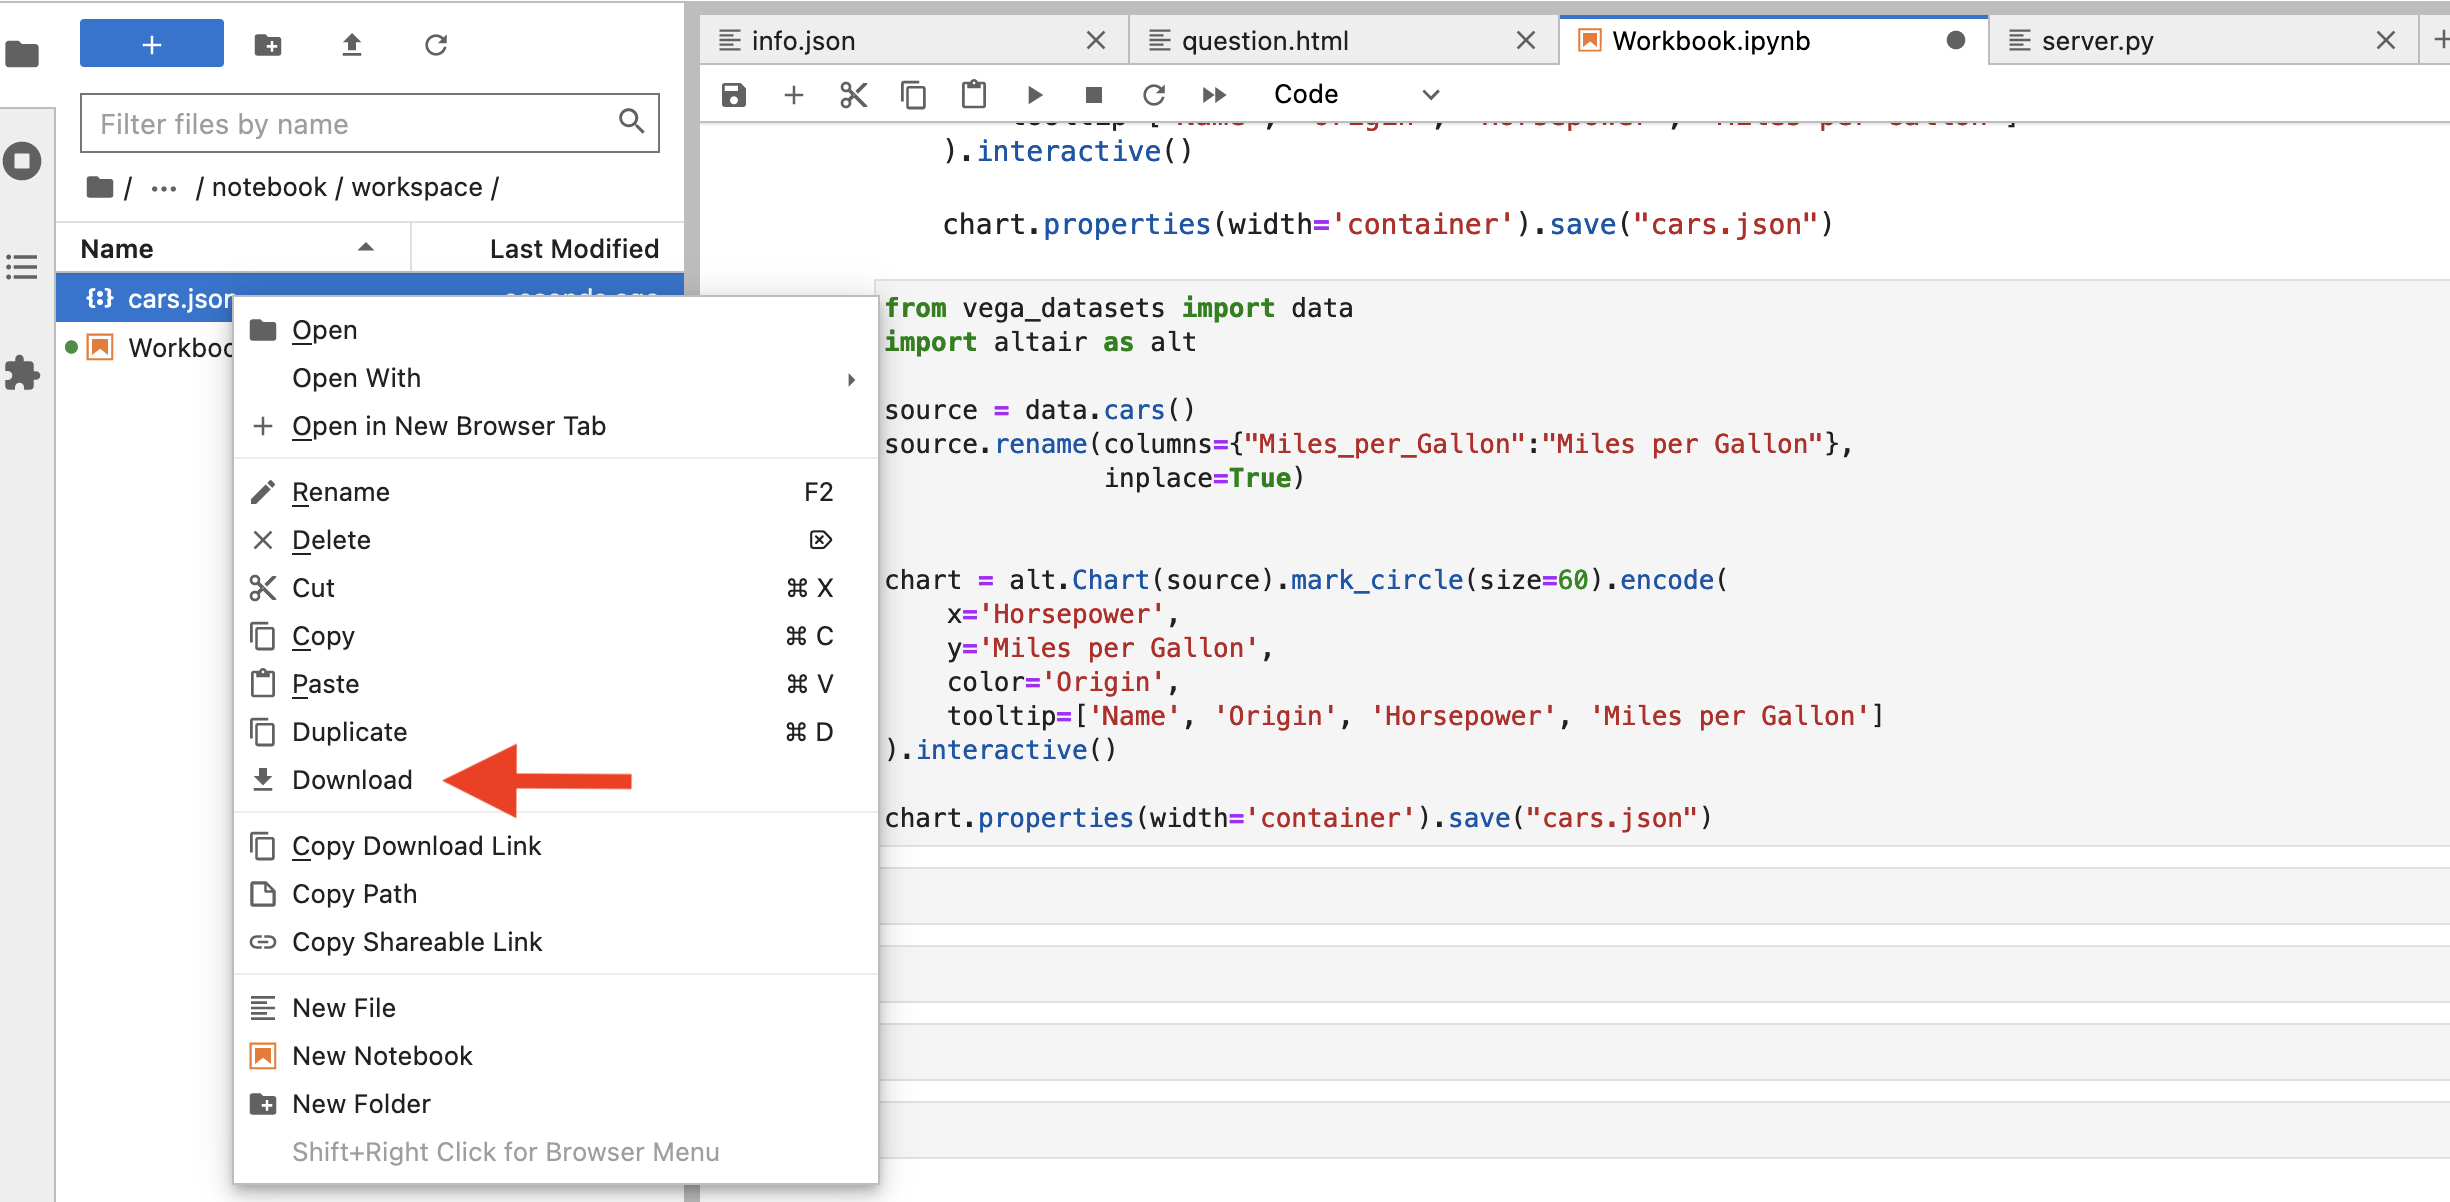

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import altair as alt

df = pd.read_csv('Chicago_Energy.csv', na_values = {'ENERGY STAR Score':0,
                                    'Year Built':0,
                                    'Primary Property Type':0,
                                    'Electricity Use (kBtu)':0})
df

,Data Year,ID,Property Name,Address,ZIP Code,Community Area,Primary Property Type,Gross Floor Area - Buildings (sq ft),Year Built,# of Buildings,...,All Other Fuel Use (kBtu),Site EUI (kBtu/sq ft),Source EUI (kBtu/sq ft),Weather Normalized Site EUI (kBtu/sq ft),Weather Normalized Source EUI (kBtu/sq ft),Total GHG Emissions (Metric Tons CO2e),GHG Intensity (kg CO2e/sq ft),Latitude,Longitude,Location
0,2016,124308,Walmart Supercenter #01-5965,10900 S. Doty Avenue,60628,PULLMAN,Wholesale Club/Supercenter,155765.0,2013.0,1,...,NaN,135.1,328.3,139.8,331.0,2941.0,18.9,41.693399,-87.598728,"(41.693399, -87.598728)"
1,2016,251322,990 West Fullerton Building,990 West Fullerton Ave,60614,LINCOLN PARK,College/University,91963.0,1980.0,1,...,NaN,69.3,158.8,73.8,163.6,835.3,9.1,41.925418,-87.653232,"(41.925418, -87.653232)"
2,2016,101770,10 and 30 South Wacker,10 South Wacker Drive,60606,LOOP,Office,2662457.0,1983.0,1,...,76507.2,68.7,214.0,68.7,214.0,33427.7,12.6,41.881607,-87.637517,"(41.8816073, -87.63751717)"
3,2016,175474,West Side Realty Corporation (300 S. Ashland A...,300 S. Ashland Ave.,60612,NEAR WEST SIDE,Office,65885.0,1968.0,1,...,NaN,93.7,294.3,93.7,294.3,1138.3,17.3,41.877588,-87.667672,"(41.877588, -87.667672)"
4,2016,251233,Clybourn,2601 N. Clybourn Street,60614,LINCOLN PARK,Retail Store,144180.0,1996.0,1,...,NaN,52.6,157.4,52.7,156.4,1327.2,9.2,41.931178,-87.674260,"(41.93117753, -87.67426011)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,2016,251526,Barry-CPS,2828 N Kilbourn Ave,60641,HERMOSA,K-12 School,78700.0,1927.0,1,...,NaN,77.0,121.2,84.1,128.7,521.4,6.6,41.932353,-87.740160,"(41.93235271, -87.74015991)"
2713,2016,253965,230 W Huron,230 W Huron St,60654,NEAR NORTH SIDE,Office,66043.0,1903.0,1,...,NaN,64.7,158.4,68.2,162.1,602.1,9.1,41.891580,-87.637837,"(41.89158015, -87.63783734)"
2714,2016,251427,Banneker Ele-CPS,6646 S Normal,60621,ENGLEWOOD,K-12 School,65017.0,2014.0,1,...,NaN,76.9,125.4,84.9,134.3,447.8,6.9,41.773223,-87.636873,"(41.773223, -87.636873)"
2715,2016,250104,Mary Hartwell Catherwood Apartments,3920-40 N CLARK ST,60613,LAKE VIEW,Multifamily Housing,240781.0,1970.0,3,...,NaN,89.1,132.7,93.7,137.6,1730.9,7.2,41.953137,-87.662016,"(41.95313687, -87.66201582)"


In [2]:
data_url= 'https://raw.githubusercontent.com/YuhanWu99/YuhanWu99.github.io/main/_data/Chicago_Energy_Benchmarking_-_2016_Data_Reported_in_2017.csv'

In [3]:
brush = alt.selection_interval(encodings=['x','y'])

In [33]:
property_counts = df['Primary Property Type'].value_counts().iloc[:11]
property_counts

Multifamily Housing                      1339
K-12 School                               392
Office                                    344
College/University                         88
Hotel                                      76
Retail Store                               56
Senior Care Community                      54
Supermarket/Grocery Store                  46
Mixed Use Property                         30
Hospital (General Medical & Surgical)      27
Residence Hall/Dormitory                   27
Name: Primary Property Type, dtype: int64

In [34]:
property_types = ['Multifamily Housing','K-12 School','Office','Hospital (General Medical & Surgical)','Hotel','Retail Store',
                  'Senior Care Community','Supermarket/Grocery Store','Mixed Use Property','Residence Hall/Dormitory']

In [35]:
filtered_df = df[(df['Year Built'] >= 1940) & (df['Year Built'] <= 2016) & df['Primary Property Type'].isin(property_types)]

In [41]:
# score = df[df['Primary Property Type'] == 'College/University']['ENERGY STAR Score'].describe()
# df['ENERGY STAR Score']

# result = df.groupby('Primary Property Type')['ENERGY STAR Score'].describe()
# print(result)


In [42]:
dropdown = alt.binding_select(options=df['Year Built'].unique())
year = alt.selection_single(fields=['Year Built'], bind=dropdown)

/opt/conda/lib/python3.8/site-packages/altair/utils/deprecation.py:65: AltairDeprecationWarning: 'selection_single' is deprecated.  Use 'selection_point'
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)


In [47]:
chart1 = alt.Chart(filtered_df).mark_rect().encode(
    alt.X('Year Built:O'),
    alt.Y('Primary Property Type:O'),
    alt.Color('Electricity Use (kBtu):Q', aggregate='mean',title='Mean Electricity Use(kBtu)')
).properties(width=400, height=200, title='Heatmap of Electricity Use by Property Type and Year'
            ).transform_filter(year).add_selection(brush, year)

chart2 = alt.Chart(filtered_df).mark_bar().encode(
    alt.X('Primary Property Type:O'),
    alt.Y('ENERGY STAR Score:Q', aggregate='mean', title='Mean ENERGY STAR Score'),
    alt.Color('ENERGY STAR Score:Q', aggregate='mean', title='Mean ENERGY STAR Score')
).properties(
    width=300,
    title='Mean ENERGY STAR Score by Property Type'
).transform_filter(brush).transform_filter(year)


In [48]:
chart = alt.HConcatChart(hconcat=[chart1,chart2]).resolve_scale(color='independent')
chart

alt.HConcatChart(...)

In [12]:
myJekyllDir = './'

In [49]:
chart.save(myJekyllDir + 'side_by_side_data_url.json')

# Contextual Visualizations

https://raw.githubusercontent.com/YuhanWu99/YuhanWu99.github.io/main/figs/1_ReportingRate.png
https://raw.githubusercontent.com/YuhanWu99/YuhanWu99.github.io/main/figs/2_EnergyStar.png
https://raw.githubusercontent.com/YuhanWu99/YuhanWu99.github.io/main/figs/3_StarByBuilding.png
https://raw.githubusercontent.com/YuhanWu99/YuhanWu99.github.io/main/figs/4_GHG.png
https://raw.githubusercontent.com/YuhanWu99/YuhanWu99.github.io/main/figs/5_EUI.png

Source:
https://www.chicago.gov/content/dam/city/progs/env/Energy-Benchmark-Reports/2020_Chicago_Energy_Benchmarking_Report.pdf

**Intro**

We complete the contextual visualizations, which includes two parts-'Overall Energy Performance' and 'Trend Analysis', by referring to the 2020 Energy Benchmark Report of Chicago city. In this section, we compare the city's perfomance from 2016, the year we analysed heavily in previous work, to 2020, the year of most recent data. And we conclude that Chicago city has done well in maintain its performance level for this 5 years, but it failed to provide any proof for significant improvements.

**OVERALL ENERGY PERFORMANCE**

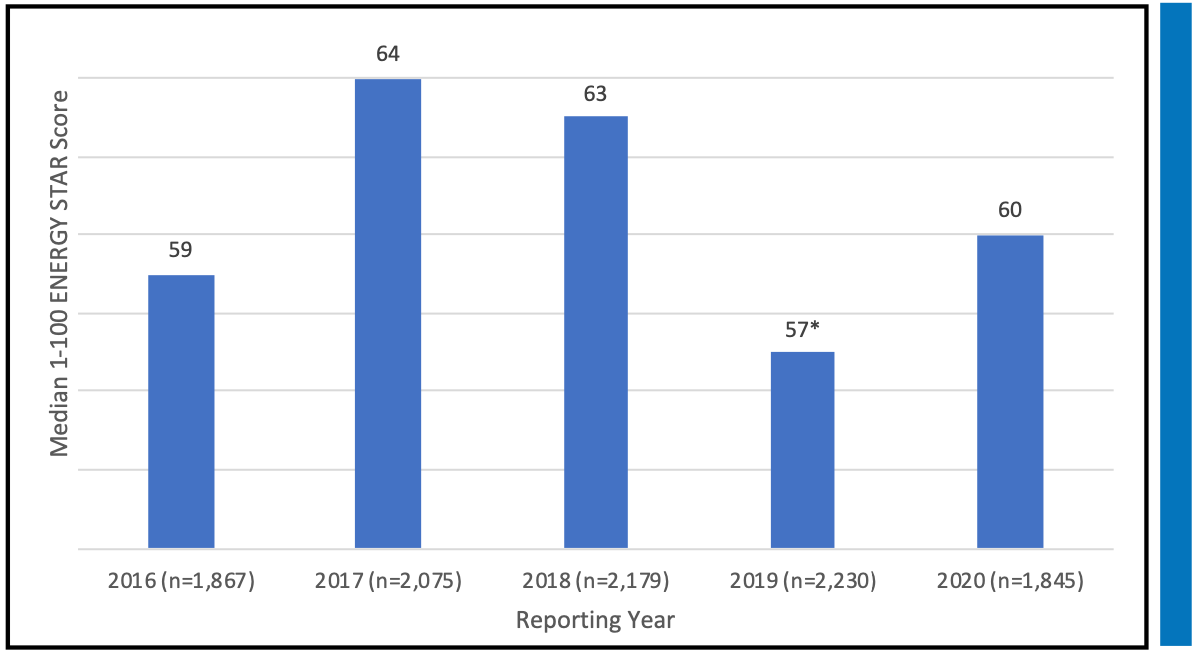

In [15]:
fig2 = Image.open('2_EnergyStar.png')
fig2

Figure 2 displays the Median ENERGY STAR Scores from 2016 to 2020.

The 1-100 ENERGY STAR score represents a property’s overall energy performance relative to similar building types across the nation, while normalizing for different climates. A score of 50 indicates energy performance at the national median, while a score of 100 represents extremely high energy performance. Scores below 50 indicate significant opportunities for improvement.

In 2020, the median ENERGY STAR score for all analyzed properties in Chicago was 60 out of 100, an increase of three points from the median of 57 in 2019. 

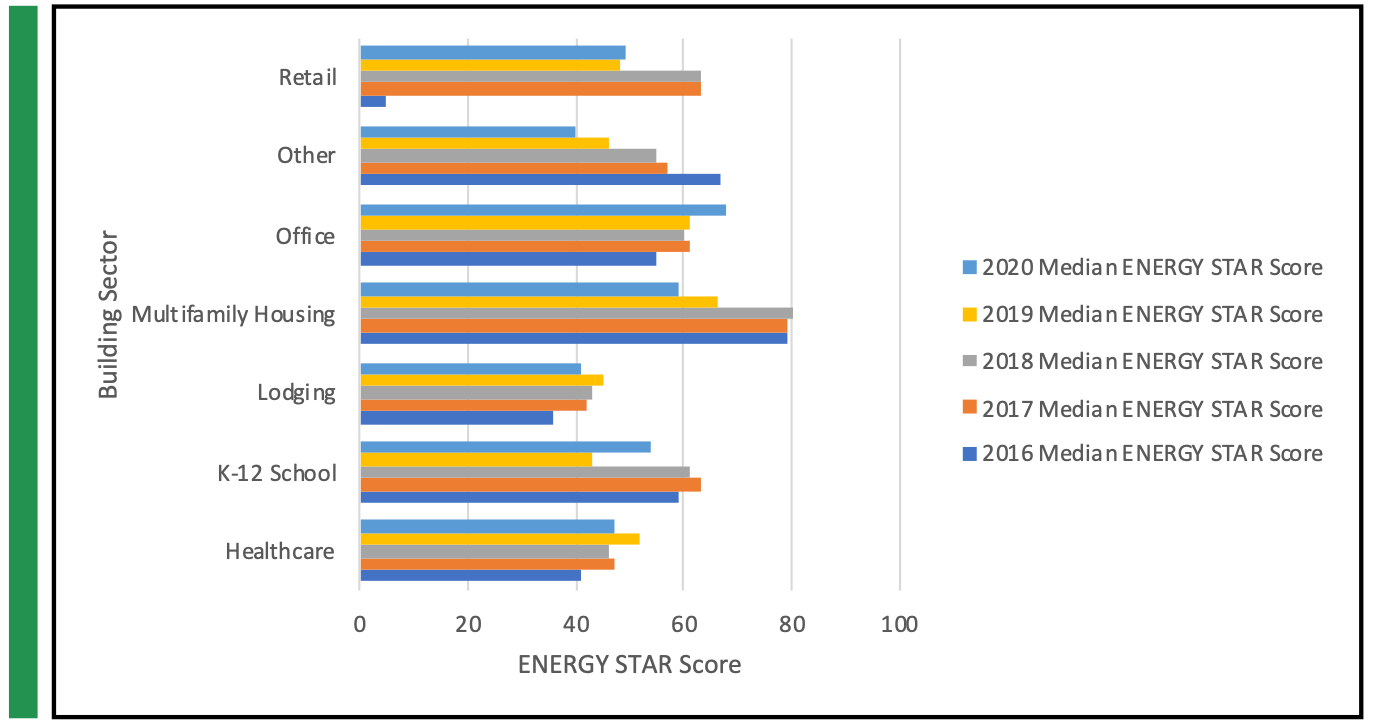

In [16]:
fig3 = Image.open('3_StarByBuilding.png')
fig3

Figure 3 displays ENERGY STAR Scores by Building Sector Reported from 2016 to 2020.

The median ENERGY STAR score has increased in the Retail, Office, and K-12 School property sectors, while the Multifamily Housing, Lodging, Other, and Healthcare sectors saw declines from 2019 to 2020. A median score of 60 is well above the national median of 50, indicating the Chicago properties over 50,000 square feet are performing slightly better than the majority of comparable buildings in the U.S.

**TREND ANALYSIS**

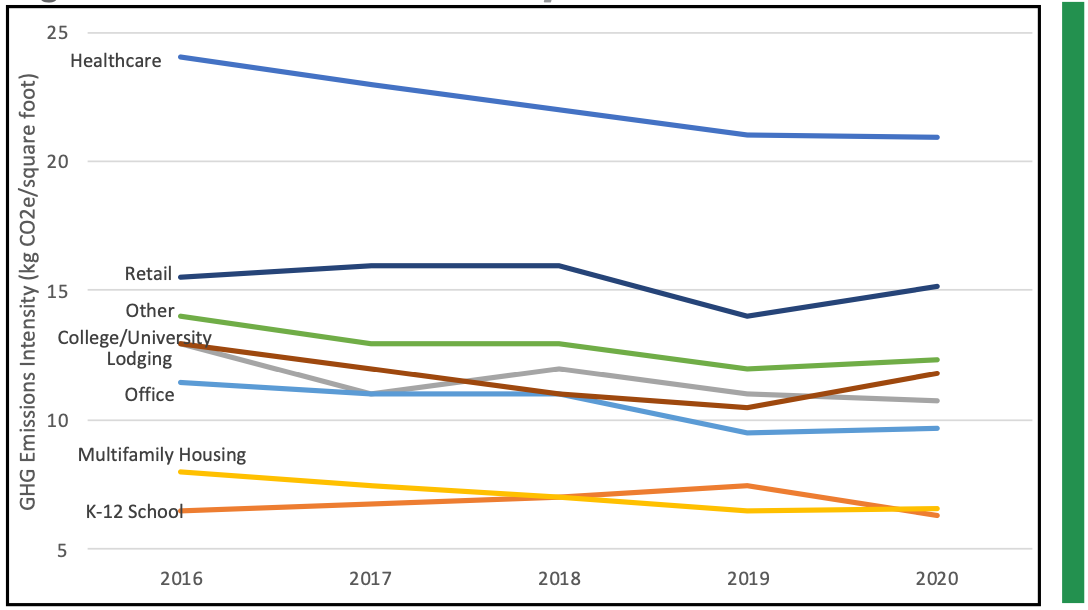

In [17]:
fig4 = Image.open('4_GHG.png')
fig4

Figure 4 display the trend of Median GHG Intensity from 2016 to 2020.

Overall, the carbon emissions per sq. ft. of space continued to decline rapidly and decreased by 25% from 2016 to 2020. All building sectors have seen decreases in the GHG intensity as shown in this figure. When comparing total GHG emissions from nearly 2,000 properties that reported in 2017 and again reported in 2020, total GHG emissions are down 9%, which equates to over 200,000 metric tons of carbon dioxide equivalents (CO2e). This reduction is equivalent to removing nearly 55,000 passenger cars from the road each year.

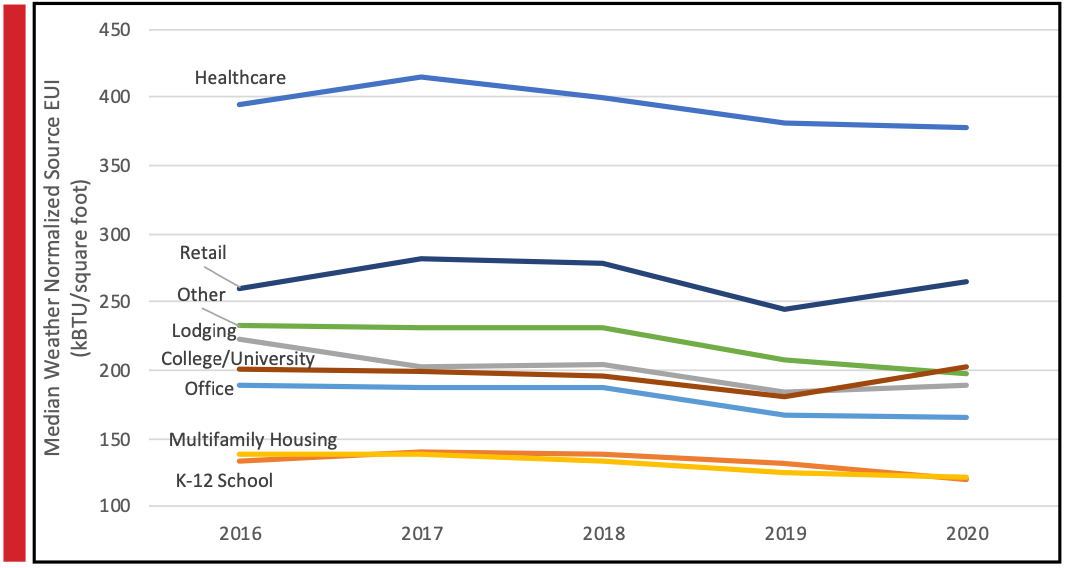

In [18]:
fig5 = Image.open('5_ EUI.png')
fig5

Figure 5 display the trend of Median Source EUI from 2016 to 2020.

Now, the final figure demonstrate the comparison over the past five years of benchmarking information shows that the median weather-normalized source energy use per sq. ft. for all reporting buildings has dropped by 7% from the 2016 to 2020 reporting years. All sectors saw decreases since the 2016 reporting year, with the exception of Retail and College/ University. The greatest improvements have been seen in the Lodging sector (18% improvement) and Office sector (15% improvement).